In [1]:
import os
import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures, MinMaxScaler,OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import zipfile 
from pathlib import Path

import missingno as msno
import pickle

In [2]:
zip_path = Path("C:\\Users\\chris\\Initiez_vous_au_ML_Ops\\Projet+Mise+en+prod+-+home-credit-default-risk.zip")
extract_dir = Path("data")

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

print("Extraction terminée !")

Extraction terminée !


# Etude de bureau_balance.csv (ensuite on étudiera bureau.csv)

In [3]:
bureau_balance = pd.read_csv(r"C:\Users\chris\Initiez_vous_au_ML_Ops\data\bureau_balance.csv")
print('Bureau balance data shape: ', bureau_balance.shape)
bureau_balance.head()

Bureau balance data shape:  (27299925, 3)


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


# colonne MONTHS_BALANCE de bureau_balance: c'est le mois de l’observation du crédit par rapport à la date de demande de crédit
# -1 = le mois précédent la demande de crédit, -2 = 2 mois avant la demande de crédit, 

# colonne STATUS de bureau_balance: représente l’état mensuel du crédit à savoir: comportement de paiement du client 
# - 0 : le client a payé à temps
# Les retards (1–5) sont des signaux de risque: 1 = retard de 1 mois, 5= retard de 5 mois !!!
# C= close et X= without information

<Axes: >

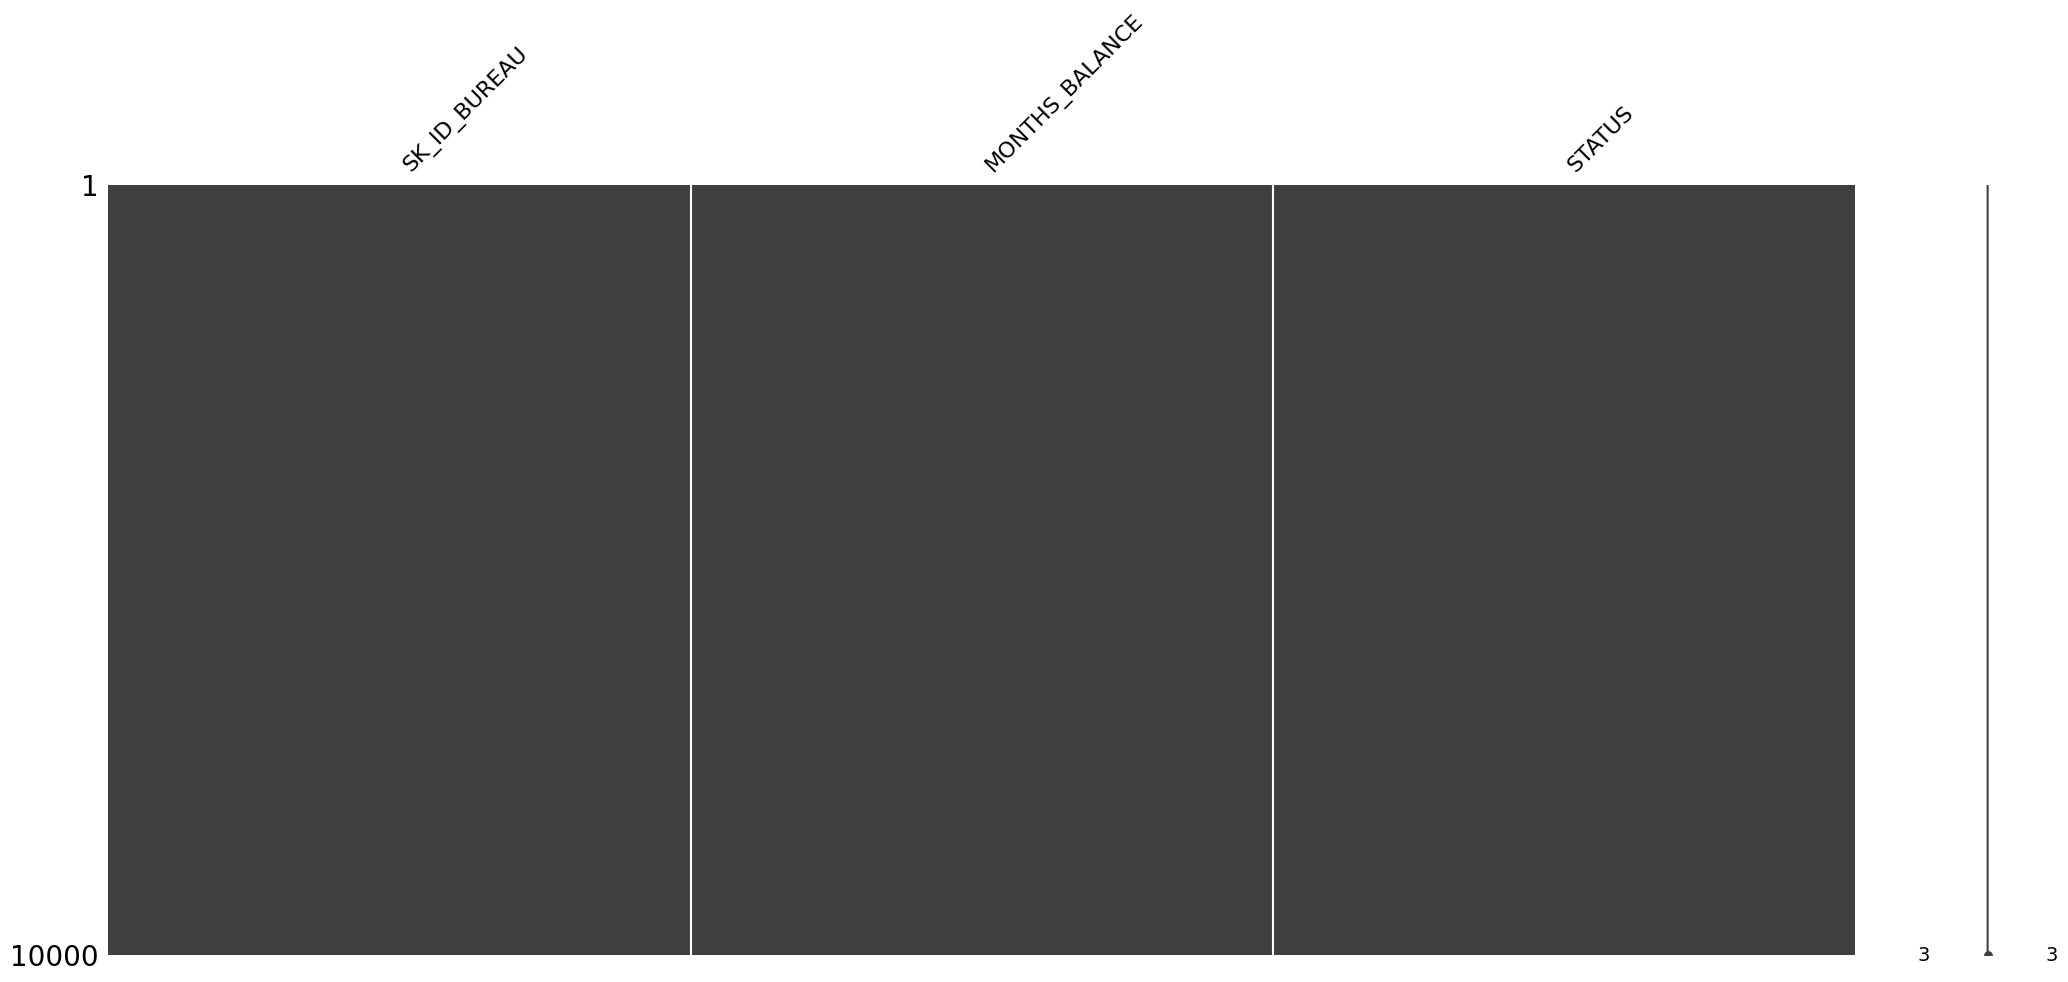

In [4]:
%matplotlib inline
msno.matrix(bureau_balance.sample(10000))

In [5]:
bureau_balance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB


# encodage de Status

In [6]:
bureau_balance["STATUS"] = bureau_balance["STATUS"].map(
    {"C": 0, "X": 1, "0": 2, "1": 3, "2": 4, "3": 5, "4": 6, "5": 7}
)

In [7]:
bureau_balance.describe()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
count,2.729992e+07,2.729992e+07,2.729992e+07
mean,6.036297e+06,-3.074169e+01,8.112387e-01
std,4.923489e+05,2.386451e+01,9.354551e-01
min,5.001709e+06,-9.600000e+01,0.000000e+00
25%,5.730933e+06,-4.600000e+01,0.000000e+00
50%,6.070821e+06,-2.500000e+01,1.000000e+00
75%,6.431951e+06,-1.100000e+01,2.000000e+00
max,6.842888e+06,0.000000e+00,7.000000e+00


In [8]:
bureau_balance[ 'MONTHS_BALANCE'].unique();

In [9]:
bureau_balance[ 'STATUS'].unique();

In [10]:
bureau_balance.isnull().mean() * 100

SK_ID_BUREAU      0.0
MONTHS_BALANCE    0.0
STATUS            0.0
dtype: float64

# Recherche de doublons dans bureau_balance

In [11]:
bureau_balance.duplicated();

# Etude de bureau.csv

In [12]:
bureau = pd.read_csv(r"C:\Users\chris\Initiez_vous_au_ML_Ops\data\bureau.csv")
print('Bureau data shape: ', bureau.shape)
bureau.head()

Bureau data shape:  (1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [13]:
bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


<Axes: >

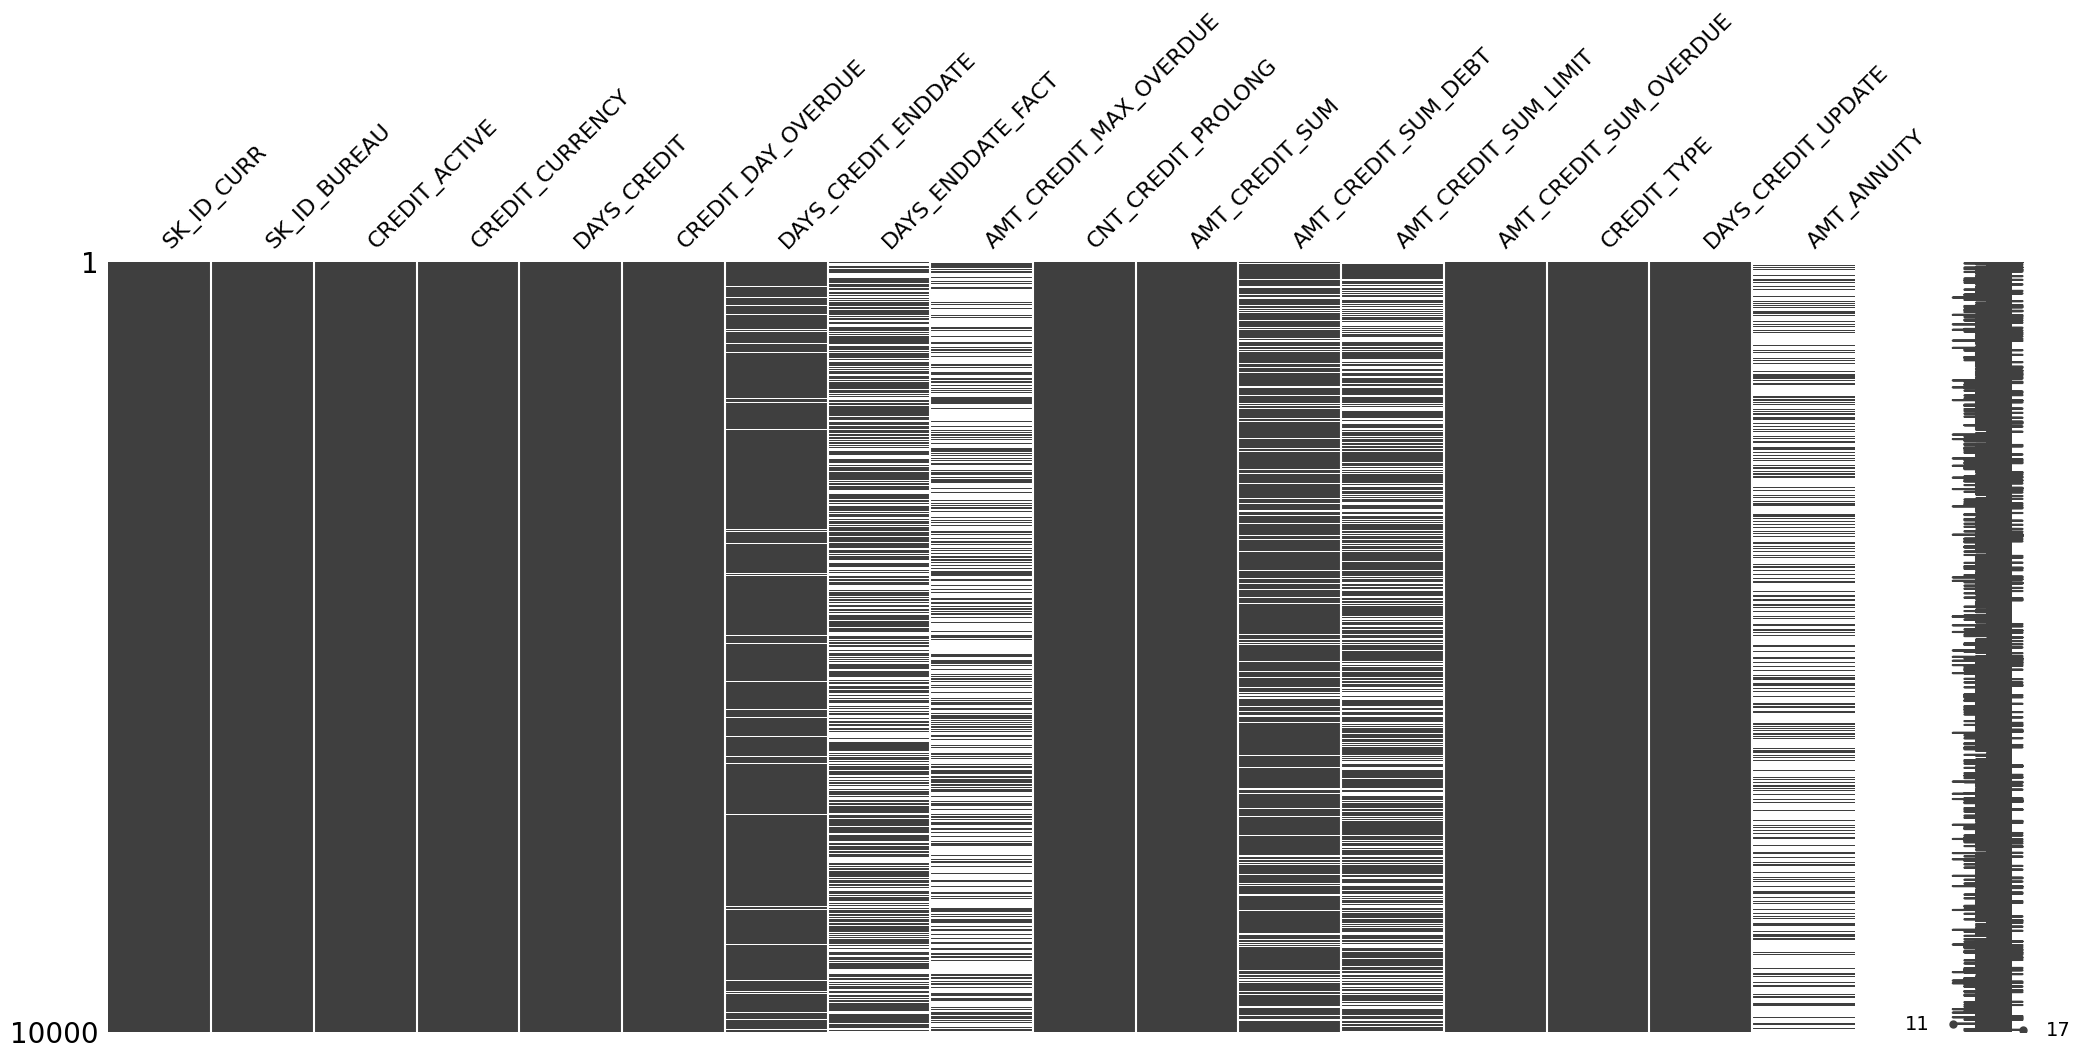

In [14]:
%matplotlib inline
msno.matrix(bureau.sample(10000))

In [15]:
bureau.isnull().mean() * 100;

In [16]:
bureau[ 'CREDIT_ACTIVE'].unique()

array(['Closed', 'Active', 'Sold', 'Bad debt'], dtype=object)

In [17]:
bureau[ 'CREDIT_CURRENCY'].unique()

array(['currency 1', 'currency 2', 'currency 4', 'currency 3'],
      dtype=object)

In [18]:
# âge du crédit
bureau[ 'DAYS_CREDIT'].unique()

array([-497, -208, -203, ...,    0,   -3,   -1], shape=(2923,))

In [19]:
bureau[ 'CREDIT_DAY_OVERDUE'].unique();

In [20]:
bureau[ 'DAYS_CREDIT_ENDDATE'].unique()

array([-153., 1075.,  528., ..., 5922., 3835., 5650.], shape=(14097,))

In [21]:
bureau[ 'DAYS_ENDDATE_FACT'].unique();

In [22]:
bureau[ 'AMT_CREDIT_MAX_OVERDUE'].unique();

In [23]:
bureau[ 'CNT_CREDIT_PROLONG'].unique();

In [24]:
bureau[ 'AMT_CREDIT_SUM'].unique()

array([ 91323.  , 225000.  , 464323.5 , ...,  77861.43, 112204.35,
       108765.72], shape=(236709,))

In [25]:
bureau[ 'AMT_CREDIT_SUM_DEBT'].unique()

array([      0.   ,  171342.   ,         nan, ...,  830860.875,
        146502.   , 1092226.5  ], shape=(226538,))

In [26]:
bureau[ 'AMT_CREDIT_SUM_LIMIT'].unique()

array([       nan, 108982.62 ,      0.   , ...,  10398.15 ,  10617.75 ,
       135035.865], shape=(51727,))

In [27]:
bureau[ 'AMT_CREDIT_SUM_LIMIT'].value_counts();

In [28]:
bureau[ 'AMT_CREDIT_SUM_OVERDUE'].unique();

In [29]:
bureau[ 'AMT_CREDIT_SUM_OVERDUE'].value_counts();

In [30]:
bureau[ 'CREDIT_TYPE'].unique();

In [31]:
bureau['DAYS_CREDIT_UPDATE'].unique()

array([  -131,    -20,    -16, ...,  -2901, -41918,  -2844], shape=(2982,))

In [32]:
bureau[ 'AMT_ANNUITY'].unique();

In [33]:
bureau.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
1716423    False
1716424    False
1716425    False
1716426    False
1716427    False
Length: 1716428, dtype: bool

# Suppression de colonnes avec majorité de NaN (AMT_Annuity,...) ou à valeur unique (credit_currency) ou inutile (Credit_Type: on va regarder quels individus sont solvables mais pas quels types de credit ils souscrivent pour simplifier)

In [34]:
bureau.drop(columns=['CREDIT_CURRENCY','DAYS_ENDDATE_FACT','AMT_ANNUITY', 'AMT_CREDIT_MAX_OVERDUE', 'CREDIT_TYPE','AMT_CREDIT_SUM_LIMIT'
                     ,'AMT_CREDIT_SUM_OVERDUE']
            , inplace=True)

# Remplacement des NaN numériques par la mediane

In [35]:
num_cols = bureau.select_dtypes(exclude='object').columns

bureau[num_cols] = bureau[num_cols].fillna(bureau[num_cols].median())

# Remplacement des NaN objets par le mode (la valeur la plus fréquente)

In [36]:
obj_cols = bureau.select_dtypes('object').columns

for col in obj_cols:
    bureau[col] = bureau[col].fillna(bureau[col].mode()[0])

# Verification du solde de NaN

In [37]:
print("NaN restants :", bureau.isnull().sum().sum())

NaN restants : 0


# encodage de la colonne Credit_Active (Closed < Active < Sold < Bad debt)

In [38]:
encoder = OrdinalEncoder(
    categories=[['Closed', 'Active', 'Sold', 'Bad debt']]
)

bureau['CREDIT_ACTIVE_ORD'] = encoder.fit_transform(
    bureau[['CREDIT_ACTIVE']]
)

# Agrégation bureau_balance par SK_ID_BUREAU (par crédit)

In [39]:

bureau_balance_agg = bureau_balance.groupby("SK_ID_BUREAU").agg(["mean", "min", "max", "sum", "size"])
bureau_balance_agg.columns = ["bureau_balance_" + "_".join(col).upper() for col in bureau_balance_agg.columns]
bureau_balance_agg.reset_index(inplace=True)

print('Bureau_balance aggregated shape:', bureau_balance_agg.shape)

Bureau_balance aggregated shape: (817395, 11)


# Fusion bureau + bureau_balance (niveau crédit)

In [40]:
bureau_fusion = bureau.merge(bureau_balance_agg, on="SK_ID_BUREAU", how="left")
print('Bureau merged with bureau_balance shape:', bureau_fusion.shape)

Bureau merged with bureau_balance shape: (1716428, 21)


In [41]:
# Traitement des NaN

# SIZE et SUM : 0 = pas de statut enregistré
for col in bureau_fusion.columns:
    if 'bureau_balance' in col and ('_SIZE' in col or '_SUM' in col):
        bureau_fusion[col] = bureau_fusion[col].fillna(0)
    
    # MEAN/MIN/MAX : 0
    elif 'bureau_balance' in col and ('_MEAN' in col or '_MIN' in col or '_MAX' in col):
        bureau_fusion[col] = bureau_fusion[col].fillna(0)

# vérification du solde de NaN

In [42]:
print("NaN restants :", bureau_balance.isnull().sum().sum())

NaN restants : 0


# Agrégation finale par SK_ID_CURR (par client)

# Sélection des colonnes numériques avant le groupby

In [43]:
numeric_cols = bureau_fusion.select_dtypes(include="number").columns.tolist()

In [44]:
bureau_agg = bureau_fusion.groupby("SK_ID_CURR")[numeric_cols].agg(["mean", "min", "max", "sum"])
bureau_agg.columns = ["bureau_" + "_".join(col).upper() for col in bureau_agg.columns]
bureau_agg.reset_index(inplace=True)

print('Final bureau_agg shape:', bureau_agg.shape)
bureau_agg.head()

Final bureau_agg shape: (305811, 81)


,SK_ID_CURR,bureau_SK_ID_CURR_MEAN,bureau_SK_ID_CURR_MIN,bureau_SK_ID_CURR_MAX,bureau_SK_ID_CURR_SUM,bureau_SK_ID_BUREAU_MEAN,bureau_SK_ID_BUREAU_MIN,bureau_SK_ID_BUREAU_MAX,bureau_SK_ID_BUREAU_SUM,bureau_DAYS_CREDIT_MEAN,...,bureau_BUREAU_BALANCE_STATUS_MAX_MAX,bureau_BUREAU_BALANCE_STATUS_MAX_SUM,bureau_BUREAU_BALANCE_STATUS_SUM_MEAN,bureau_BUREAU_BALANCE_STATUS_SUM_MIN,bureau_BUREAU_BALANCE_STATUS_SUM_MAX,bureau_BUREAU_BALANCE_STATUS_SUM_SUM,bureau_BUREAU_BALANCE_STATUS_SIZE_MEAN,bureau_BUREAU_BALANCE_STATUS_SIZE_MIN,bureau_BUREAU_BALANCE_STATUS_SIZE_MAX,bureau_BUREAU_BALANCE_STATUS_SIZE_SUM
0,100001,100001.0,100001,100001,700007,5896633.000,5896630,5896636,41276431,-735.000000,...,3.0,15.0,13.571429,2.0,33.0,95.0,24.571429,2.0,52.0,172.0
1,100002,100002.0,100002,100002,800016,6153272.125,6113835,6158909,49226177,-874.000000,...,3.0,22.0,23.250000,6.0,40.0,186.0,13.750000,4.0,22.0,110.0
2,100003,100003.0,100003,100003,400012,5885878.500,5885877,5885880,23543514,-1400.750000,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,100004,100004.0,100004,100004,200008,6829133.500,6829133,6829134,13658267,-867.000000,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,100005,100005.0,100005,100005,300015,6735201.000,6735200,6735202,20205603,-190.666667,...,2.0,6.0,10.000000,5.0,15.0,30.0,7.000000,3.0,13.0,21.0


# Encoder CREDIT_ACTIVE en colonnes binaires

In [45]:
bureau_dummies = pd.get_dummies(bureau_fusion[["SK_ID_CURR", "CREDIT_ACTIVE"]], 
                                 columns=["CREDIT_ACTIVE"])
bureau_dummies_agg = bureau_dummies.groupby("SK_ID_CURR").sum()

# Puis merger avec bureau_agg à la fin
bureau_agg = bureau_agg.merge(bureau_dummies_agg, on="SK_ID_CURR", how="left")

In [46]:
bureau_agg.columns.tolist()

['SK_ID_CURR',
 'bureau_SK_ID_CURR_MEAN',
 'bureau_SK_ID_CURR_MIN',
 'bureau_SK_ID_CURR_MAX',
 'bureau_SK_ID_CURR_SUM',
 'bureau_SK_ID_BUREAU_MEAN',
 'bureau_SK_ID_BUREAU_MIN',
 'bureau_SK_ID_BUREAU_MAX',
 'bureau_SK_ID_BUREAU_SUM',
 'bureau_DAYS_CREDIT_MEAN',
 'bureau_DAYS_CREDIT_MIN',
 'bureau_DAYS_CREDIT_MAX',
 'bureau_DAYS_CREDIT_SUM',
 'bureau_CREDIT_DAY_OVERDUE_MEAN',
 'bureau_CREDIT_DAY_OVERDUE_MIN',
 'bureau_CREDIT_DAY_OVERDUE_MAX',
 'bureau_CREDIT_DAY_OVERDUE_SUM',
 'bureau_DAYS_CREDIT_ENDDATE_MEAN',
 'bureau_DAYS_CREDIT_ENDDATE_MIN',
 'bureau_DAYS_CREDIT_ENDDATE_MAX',
 'bureau_DAYS_CREDIT_ENDDATE_SUM',
 'bureau_CNT_CREDIT_PROLONG_MEAN',
 'bureau_CNT_CREDIT_PROLONG_MIN',
 'bureau_CNT_CREDIT_PROLONG_MAX',
 'bureau_CNT_CREDIT_PROLONG_SUM',
 'bureau_AMT_CREDIT_SUM_MEAN',
 'bureau_AMT_CREDIT_SUM_MIN',
 'bureau_AMT_CREDIT_SUM_MAX',
 'bureau_AMT_CREDIT_SUM_SUM',
 'bureau_AMT_CREDIT_SUM_DEBT_MEAN',
 'bureau_AMT_CREDIT_SUM_DEBT_MIN',
 'bureau_AMT_CREDIT_SUM_DEBT_MAX',
 'bureau_AMT_CRE

In [47]:
with open('bureau_agg.pkl', 'wb') as f:
    pickle.dump(bureau_agg, f)